# 1. Introduction — context

This notebook explores the **AI-Assisted Hiring Fairness and Bias Audit Dataset** from Kaggle (author: Zulqarnain11). The dataset contains **1500 simulated recruitment records**, where each row represents one fictional job candidate and includes attributes such as years of experience, education level, skill fit, an AI-generated screening score, a human reviewer's score, and the resulting hiring decisions.

**Important constraint:** the data is **simulated**, not collected from real hiring processes. Any pattern found here describes the synthetic generator, not real-world recruitment. The dataset also lacks protected attributes (gender, ethnicity, age), so it cannot be used to audit those forms of bias. However, age can be indirectly deduced from years of experience. 

The driving question: **how do AI scores and human scores agree or disagree across job categories and candidate profiles?**

# 2. Loading and mechanical inspection

Data is loaded from the CSV and the schema is inspected using `df.info()`, `df.head()`, `df.describe()` and `df.isna().sum()`. From this initial "mechanical" pass we can see the shape, dtypes, first rows and summary statistics of the numeric columns as well as check for missing values. These observations will inform any following decisions regarding typing or other transformations carried out next in Data Cleaning.

In [1]:
# import json
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# import ipywidgets as widgets
# from IPython.display import display, clear_output, HTML

%matplotlib inline
sns.set_theme(style="darkgrid", palette="muted")
#plt.rcParams['figure.dpi'] = 100

# load dataframe from dataset file
df = pd.read_csv("data/ai_hiring_audit_dataset.csv")

# show raw dataframe definition
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Candidate_ID        1500 non-null   int64  
 1   Job_Category        1500 non-null   str    
 2   Years_Experience    1500 non-null   int64  
 3   Education_Level     1500 non-null   str    
 4   Skill_Fit_Score     1500 non-null   float64
 5   AI_Score            1500 non-null   float64
 6   Human_Score         1500 non-null   float64
 7   AI_Decision         1500 non-null   int64  
 8   Human_Decision      1500 non-null   int64  
 9   Final_Decision      1500 non-null   int64  
 10  Score_Divergence    1500 non-null   float64
 11  Decision_Agreement  1500 non-null   int64  
dtypes: float64(4), int64(6), str(2)
memory usage: 140.8 KB


In [2]:
# how many rows and columns, and what does a row look like?
print(f"Rows, columns: {df.shape}")
df.head()

Rows, columns: (1500, 12)


,Candidate_ID,Job_Category,Years_Experience,Education_Level,Skill_Fit_Score,AI_Score,Human_Score,AI_Decision,Human_Decision,Final_Decision,Score_Divergence,Decision_Agreement
0,20000,HR Specialist,16,PhD,55.09,41.45,40.68,0,0,0,0.77,1
1,20001,Marketing Manager,0,Bachelors,9.77,6.69,0.00,0,0,0,6.69,1
2,20002,Software Engineer,11,PhD,60.09,44.05,49.92,0,0,0,-5.87,1
3,20003,Data Analyst,8,Bachelors,29.71,33.61,23.96,0,0,0,9.65,1
4,20004,Data Analyst,9,Masters,58.10,58.55,70.97,0,1,1,-12.42,0


In [3]:
# numeric summary of every column
df.describe()

,Candidate_ID,Years_Experience,Skill_Fit_Score,AI_Score,Human_Score,AI_Decision,Human_Decision,Final_Decision,Score_Divergence,Decision_Agreement
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,20749.500000,9.784000,43.856433,38.211987,45.982987,0.112667,0.153333,0.180000,-7.771000,0.906000
std,433.157015,6.113995,19.984674,20.985307,22.163888,0.316290,0.360429,0.384316,12.078434,0.291926
min,20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-52.230000,0.000000
25%,20374.750000,4.000000,28.957500,22.872500,30.270000,0.000000,0.000000,0.000000,-16.085000,1.000000
50%,20749.500000,10.000000,43.025000,37.265000,45.175000,0.000000,0.000000,0.000000,-7.420000,1.000000
75%,21124.250000,15.000000,58.822500,53.037500,62.047500,0.000000,0.000000,0.000000,0.062500,1.000000
max,21499.000000,20.000000,100.000000,100.000000,100.000000,1.000000,1.000000,1.000000,35.240000,1.000000


In [4]:
# missing values per column
df.isna().sum()

Candidate_ID          0
Job_Category          0
Years_Experience      0
Education_Level       0
Skill_Fit_Score       0
AI_Score              0
Human_Score           0
AI_Decision           0
Human_Decision        0
Final_Decision        0
Score_Divergence      0
Decision_Agreement    0
dtype: int64

**Observations from the mechanical inspection.**

- **Shape.** 1500 rows × 12 columns
- **Schema.** `df.info()` shows 2 `object`, 4 `float64` and 6 `int64` columns. The two `object` columns (`Job_Category` and `Education_Level`) are strings. Transformations such as typing will be determined in Data Cleaning. The six `int64` columns include three binary `_Decision` fields (1 = hire, 0 = reject) and `Decision_Agreement` (1 = AI and human agree).
- **Missing values.** Running `df.isna().sum()` is part of the routine to get a clear understanding of the data and assess the need for intervention. Here it returns zero for every column but on a real (non-simulated) dataset the same call would tell us where to drop, impute or flag gaps and highlight any pattern of missing data. For example, job categories or scores might contain missing values and that pattern would itself be a signal worth investigating.
- **Scales.** `AI_Score`, `Human_Score`, `Skill_Fit_Score` and `Score_Divergence` are continuous numerics. Their ranges and means from `df.describe()` show whether the AI and human reviewers operate on comparable scales and how large the typical divergence is between them.

# 3. Data cleaning

Every transformation below is preceded by a short justification for it's use. The order is meaningful with inspections that decide whether an action is needed (duplicates, out-of-domain categories, sentinel values) occuring first followed by the type and indexing decisions. Lastly, `df.info()` is called again to confrim the schema revisions.

## 3.1 Duplicate rows

A duplicated row would double-count any given candidate's scores again in every aggregate that follows. Duplicates can occur during exports, after a merge or an export-then-reimport. Completing this check is a sound methodology and worth running before any `groupby` or mean as the duplicated values would diminish reliability and accuracy of the analysis. 

In [5]:
# any row that exactly repeats another?
df.duplicated().sum()

np.int64(0)

## 3.2 Out-of-domain category values

For the two text columns we want to confirm that every entry belongs to a known, documented category. A stray `"Bachelors "` with a trailing space, or a typo like `"Bahcelors"`, is technically a distinct value to pandas and would silently split any aggregate. `value_counts(dropna=False)` lists every unique value with its frequency, which is enough to spot oddities.

In [6]:
# every unique value for the two string columns, with counts
for col in ["Job_Category", "Education_Level"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- Job_Category ---
Job_Category
Marketing Manager    413
HR Specialist        402
Software Engineer    357
Data Analyst         328
Name: count, dtype: int64

--- Education_Level ---
Education_Level
Bachelors    677
Masters      501
PhD          163
Associate    159
Name: count, dtype: int64



## 3.3 Sentinel values

`df.isna()` only catches `NaN` / `None`. A sanity check on numeric columns facilitates a quick check for values outside the expected range. Here `Years_Experience`, the three score columns (`Skill_Fit_Score`, `AI_Score`, `Human_Score`) and the four binary `*_Decision` / `Decision_Agreement` columns should all be ≥ 0. `Score_Divergence` is excluded from this check because it is a *signed* difference (AI minus Human) meaning a negative value there is not a sentinel but a legitimate signal that the AI scored a candidate lower than the human reviewer.

In [7]:
# any negative values in columns that should be non-negative?
# Score_Divergence is excluded because it is a signed difference (AI minus Human).
non_neg_cols = [c for c in df.select_dtypes(include="number").columns if c != "Score_Divergence"]
(df[non_neg_cols] < 0).sum()

Candidate_ID          0
Years_Experience      0
Skill_Fit_Score       0
AI_Score              0
Human_Score           0
AI_Decision           0
Human_Decision        0
Final_Decision        0
Decision_Agreement    0
dtype: int64

## 3.4 Type conversions and indexing

With the inspections, dtype decisions can be made:

- **`Job_Category` dtype is converted to `category`**, an enum of four values, since ordering the values alphabtically is sufficent. Using `category` saves memory and enforces constraint.
- **`Education_Level` is converted to an ordered `category`**. Providing an explicit order (`Associate < Bachelors < Masters < PhD`) is applied so sorting and group ordering maintain the inherent meaningfullness of the categorization.
- **`AI_Decision`, `Human_Decision`, `Final_Decision`, `Decision_Agreement` - `bool`** because these columns only hold {0, 1} `bool` dtype makes the most sense.
- **`Candidate_ID` - index** because it is the row identifier, not a feature. There are no meaningful analytics or conclutions to be drawn from it.

In [8]:
# 1. ordered category for Education_Level, plain category for Job_Category
education_order = ["Associate", "Bachelors", "Masters", "PhD"]
df["Education_Level"] = pd.Categorical(
    df["Education_Level"], categories=education_order, ordered=True
)
df["Job_Category"] = df["Job_Category"].astype("category")

# 2. binary decision columns become bool
decision_cols = ["AI_Decision", "Human_Decision", "Final_Decision", "Decision_Agreement"]
df[decision_cols] = df[decision_cols].astype(bool)

# 3. Candidate_ID is the row identifier, not a feature
df = df.set_index("Candidate_ID")

## 3.5 Verification

A second `df.info()` confirms the schema after cleaning: the two text columns are now `category` (one of them ordered), the four decision columns are `bool`, and `Candidate_ID` is the index rather than a column.

In [9]:
# schema after cleaning
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 20000 to 21499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Job_Category        1500 non-null   category
 1   Years_Experience    1500 non-null   int64   
 2   Education_Level     1500 non-null   category
 3   Skill_Fit_Score     1500 non-null   float64 
 4   AI_Score            1500 non-null   float64 
 5   Human_Score         1500 non-null   float64 
 6   AI_Decision         1500 non-null   bool    
 7   Human_Decision      1500 non-null   bool    
 8   Final_Decision      1500 non-null   bool    
 9   Score_Divergence    1500 non-null   float64 
 10  Decision_Agreement  1500 non-null   bool    
dtypes: bool(4), category(2), float64(4), int64(1)
memory usage: 67.7 KB


# 4. Exploration through visualization

Each chart below answers a specific question about the data. Between charts, what each visualization deplicts about the data is descripted as well as why it matters.

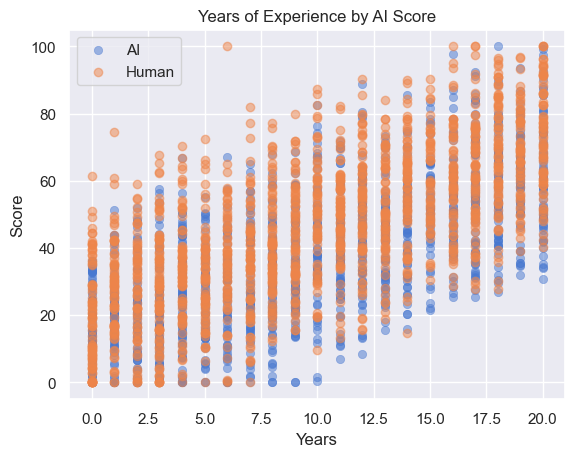

In [10]:
plt.scatter(df["Years_Experience"], df["AI_Score"],
            alpha=0.5, label="AI", linewidth=0.5)
plt.scatter(df["Years_Experience"], df["Human_Score"],
            alpha=0.5, label="Human")
plt.xlabel("Years")
plt.ylabel("Score")
plt.title("Years of Experience by AI Score")
plt.legend()
plt.grid(True)
plt.show()

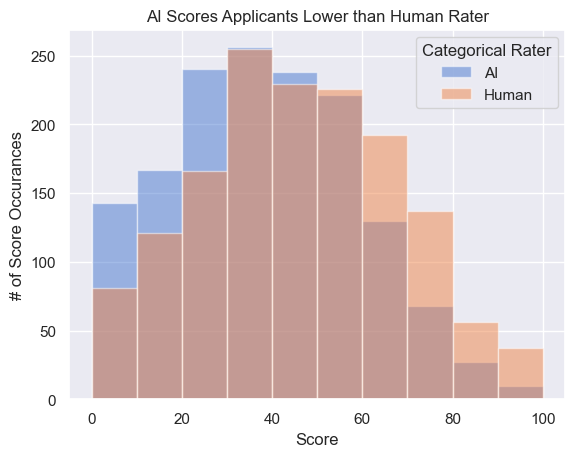

In [11]:
plt.hist(df["AI_Score"], alpha=0.5, label="AI")
plt.hist(df["Human_Score"], alpha=0.5, label="Human")
plt.xlabel("Score")
plt.ylabel("# of Score Occurances")
plt.legend(title="Categorical Rater")
plt.title("AI Scores Applicants Lower than Human Rater")
plt.grid(True)
plt.show()

# 5. Conclusion — what I learned and what the data cannot tell

_TODO_ summarise the patterns that emerged from the visualizations
- AI systematically scores candidates lower than the human reviewer
- divergence varies by job category or education level
- list questions that remain open
- explicitly name the limits of this dataset

**Epistemological boundary** Because the data is simulated, none of the findings transfer to real recruitment systems. The findings describe the synthetic generator only. The dataset contains no protected attributes (gender, ethnicity, age), so audits of those forms of bias are out of scope. Sampling, labelling and selection assumptions made by the dataset's author are also not documented and cannot be verified from the CSV alone.